# Full Green Function Figures — Publish Version

This notebook reproduces all figures from Full_GreenFunction_2_01_20.ipynb by loading the saved arrays from Full_GreenFunction_2_01_20_plot_arrays.h5.

In [2]:
using Plots
using LaTeXStrings
using HDF5

default(fontfamily = "Times")

h5file = joinpath(@__DIR__, "Full_GreenFunction_src_2_01_obs20_plot_arrays.h5")

TimeDomainTimes = h5read(h5file, "raw/TimeDomainTimes")
TimeDomainData  = h5read(h5file, "raw/TimeDomainData")
t_arr           = h5read(h5file, "raw/t_arr")
QNM_arr         = h5read(h5file, "raw/QNM_arr")
G_tail_arr      = h5read(h5file, "raw/G_tail_arr")
t_shifted       = h5read(h5file, "raw/t_shifted")
Filtered_ψ      = h5read(h5file, "raw/Filtered_ψ")

r  = 20.0
r′ = 2.01
rs  = r  + 2*log(r/2 - 1)
r′s = r′ + 2*log(r′/2 - 1)

@show h5file

h5file = "/Users/apple/Desktop/Published_Papers/Decomposition_of_Schwarzschild_GF/Data/Full_GreenFunction_src_2_01_obs20_plot_arrays.h5"


"/Users/apple/Desktop/Published_Papers/Decomposition_of_Schwarzschild_GF/Data/Full_GreenFunction_src_2_01_obs20_plot_arrays.h5"

## Logarithmic Scale

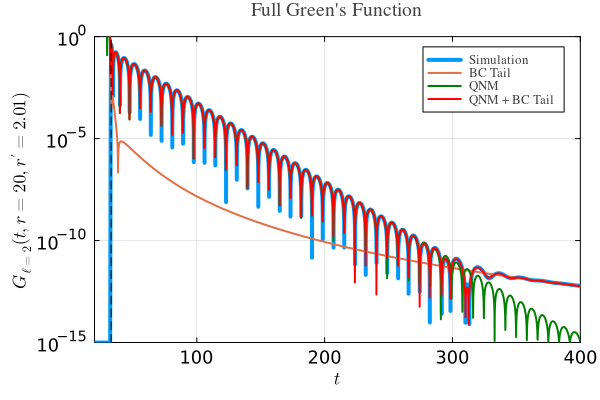

In [3]:
plt1 = plot(TimeDomainTimes .- 0.1, abs.(TimeDomainData) .+ 1e-15, label = " Simulation ", lw = 4, ls = :solid)
       plot!(t_arr .- 0.1, abs.(G_tail_arr), label = " BC Tail ", lw = 2)
       plot!(t_arr .- 0.1, abs.(real.(QNM_arr .* (2/(2*pi)))) .+ 1e-15, label = " QNM ", lw = 2, color = :green)
       plot!(t_arr .- 0.1, abs.(real.(QNM_arr .* (2/(2*pi))) .+ G_tail_arr) .+ 1e-15, label = " QNM + BC Tail ", lw = 2, color = :red, linestyle = :solid)
       vline!([rs - r′s], label = "", linestyle = :dash, color = :black)
       plot!(frame = :box, yscale = :log10, title = "Full Green's Function", xlabel = L"t", ylabel = L"G_{\ell = 2}(t, r=20, r^\prime=2.01)", legend = :topright, xtickfont = font(12), ytickfont = font(12), guidefont = font(12), titlefont = font(12, "Times"), legendfont = font(8, "Times"), margin = 3Plots.mm)
       xlims!(20, 400)
       ylims!(1e-15, 1e0)
savefig("Full_GreenFunctionA_src2_01_obs20.pdf")
plt1

## Linear Scale

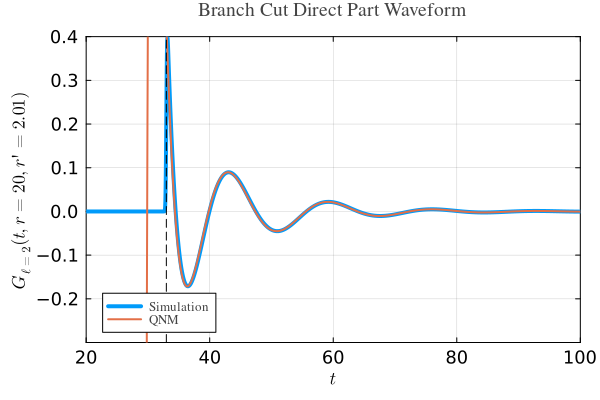

In [4]:
plt2 = plot(TimeDomainTimes .- 0.1, real.(TimeDomainData), label = " Simulation ", lw = 4)
       plot!(t_arr .- 0.1, real.(QNM_arr .* (2/(2*pi))) .+ 1e-10, label = " QNM ", lw = 2)
       vline!([rs - r′s], label = "", linestyle = :dash, color = :black)
       vline!([rs + r′s], label = "", linestyle = :dot, color = :black)
       plot!(frame = :box, title = "Branch Cut Direct Part Waveform", xlabel = L"t", ylabel = L"G_{\ell = 2}(t, r=20, r'=2.01)", legend = :bottomleft, xtickfont = font(12), ytickfont = font(12), guidefont = font(12), titlefont = font(12, "Times"), legendfont = font(8, "Times"), margin = 3Plots.mm)
       xlims!(20, 100)
       ylims!(-0.3, 0.4)
savefig(plt2,"QNMSum_WaveformA_src2_01_obs20.pdf")
plt2

## Apply Sizheng Ma's QNM Filter

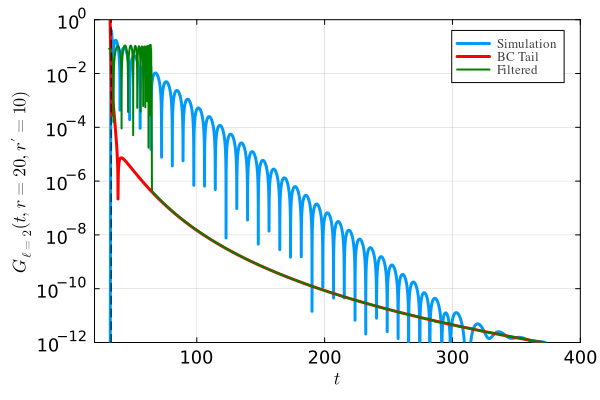

In [5]:
plt3 = plot(TimeDomainTimes .- 0.1, abs.(TimeDomainData) .+ 1e-15, label = " Simulation ", lw = 3, ls = :solid)
       plot!(t_arr[5:end] .- 0.1, abs.(G_tail_arr[5:end]), label = " BC Tail ", lw = 3, color = :red)
       plot!(t_shifted, abs.(real.(Filtered_ψ)), label = " Filtered ", lw = 2, color = :green)
       vline!([rs - r′s], label = "", linestyle = :dash, color = :black)
       vline!([rs + r′s], label = "", linestyle = :dot, color = :black)
       plot!(frame = :box, yscale = :log10, xlabel = L"t", ylabel = L"G_{\ell = 2}(t, r=20, r^\prime=10)", legend = :topright, xtickfont = font(12), ytickfont = font(12), guidefont = font(12), titlefont = font(12, "Times"), legendfont = font(8, "Times"), margin = 3Plots.mm)
       xlims!(20, 400)
       ylims!(1e-12, 1e0)
savefig(plt3,"Filter_QNM_src2_01_obs20.pdf")
plt3
